NAC Paper Results

2026-05-24 11:10:55.324689: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-24 11:10:55.336526: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779592255.349945   20563 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779592255.353936   20563 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-24 11:10:55.368281: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr


===== Training NSAC =====


2026-05-24 11:10:59.410810: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2026-05-24 11:10:59.410846: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:137] retrieving CUDA diagnostic information for host: server-application-intelligence
2026-05-24 11:10:59.410851: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:144] hostname: server-application-intelligence
2026-05-24 11:10:59.410971: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:168] libcuda reported version is: 470.182.3
2026-05-24 11:10:59.410989: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:172] kernel reported version is: 470.182.3
2026-05-24 11:10:59.410992: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:259] kernel version seems to match DSO: 470.182.3
/home/ustc15/anaconda3/envs/nsac/lib/pyth


===== Training Gaussian-MLE =====


/home/ustc15/anaconda3/envs/nsac/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 40 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



===== Training Deep-Ensemble =====

===== Training MC-Dropout =====
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step

===== Training Evidential =====


/home/ustc15/anaconda3/envs/nsac/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 74 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



===== Training SDE-Net =====


/home/ustc15/anaconda3/envs/nsac/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/ustc15/anaconda3/envs/nsac/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


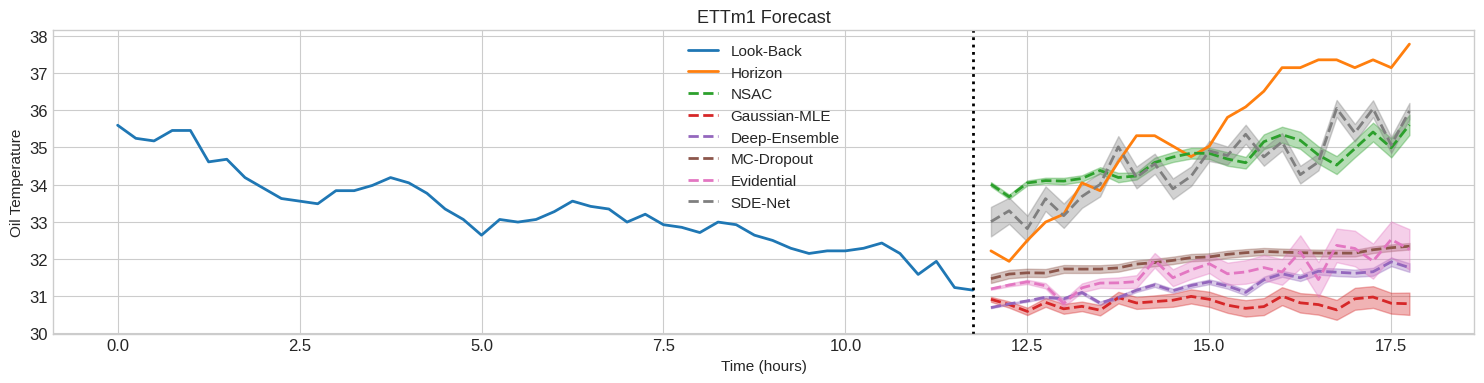

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from neuronal_attention_circuit import NAC

import pandas as pd
import numpy as np
import tensorflow as tf


from evidential_deep_learning.layers import DenseNormalGamma
from evidential_deep_learning.losses import EvidentialRegression


from sklearn.preprocessing import MinMaxScaler
from baselines import GMLE, DeepEnsemble, Evidential, MC_dropout, SDE_Net
from neuronal_attention_circuit import NAC
from ouwrap import OUWrap
from losses import NSACLoss, NLL
from neuronal_stochastic_attention_circuit import NSAC

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 11,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "lines.linewidth": 2.0,
    "lines.markersize": 3,
})

# config
LOOKBACK = 48      
HORIZON = 24
BATCH_SIZE = 64
EPOCHS = 50
TARGET_COL = 'OT'  # Oil Temperature

BASE_MODEL_NAME = 'ETTm1_forecast'
WEIGHTS_DIR = 'forecast_weights'
PLOTS_DIR = 'plots'
os.makedirs(WEIGHTS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)



# data preprocess
def prepare_ettm1_data(file_path):
    df = pd.read_csv(file_path)
    df = df.iloc[:5000]
    features = df.drop(columns=['date'])
    n_features = features.shape[1]
    n = len(features)
    train_df = features[:int(n*0.8)]
    val_df = features[int(n*0.8):int(n*0.9)]
    test_df = features[int(n*0.9):]

    scaler = MinMaxScaler()
    scaler.fit(train_df)

    train_s = scaler.transform(train_df)
    val_s = scaler.transform(val_df)
    test_s = scaler.transform(test_df)

    def create_windows(data):
        X, y = [], []
        for i in range(len(data) - LOOKBACK - HORIZON):
            X.append(data[i:i+LOOKBACK, :])
            y.append(data[i+LOOKBACK:i+LOOKBACK+HORIZON, -1])
        return np.array(X), np.array(y)

    X_train, y_train = create_windows(train_s)
    X_val, y_val = create_windows(val_s)
    X_test, y_test = create_windows(test_s)
    return X_train, y_train, X_val, y_val, X_test, y_test, scaler, n_features

X_train, y_train, X_val, y_val, X_test, y_test, scaler, n_feats= prepare_ettm1_data('ETTm1.csv')

def inverse_temp(scaled_vals, scaler):
    dummy = np.zeros((len(scaled_vals), scaler.n_features_in_))
    dummy[:, -1] = scaled_vals  # target column
    return scaler.inverse_transform(dummy)[:, -1]

def plot_forecasts(num_samples=5, start_idx=0):
    color_list = ["tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan"]
    scales = {"NSAC": 10.0,  "Gaussian-MLE": 3.0,  "Deep-Ensemble": 2.5,  "MC-Dropout": 0.001,  "Evidential": 6.0,  "SDE-Net": 0.0009,}

    time_axis = np.arange(LOOKBACK + HORIZON) * 0.25
    idxs = list(range(start_idx, start_idx + num_samples))
    history = np.mean([inverse_temp(X_test[i][:, -1], scaler) for i in idxs], axis=0 )
    true_vals = np.mean([inverse_temp(y_test[i], scaler) for i in idxs], axis=0)

    plt.figure(figsize=(15, 4))
    plt.plot(time_axis[:LOOKBACK], history, label="Look-Back", linewidth=2)
    plt.plot(time_axis[LOOKBACK:], true_vals, label="Horizon", linewidth=2)
    temp_range = scaler.data_max_[-1] - scaler.data_min_[-1]

    for i, name in enumerate(MODEL_LIST):
        color = color_list[i % len(color_list)]
        mu, std = preds[name]
        avg_mu = np.mean([inverse_temp(mu[j], scaler) for j in idxs], axis=0)
        avg_std = np.mean([std[j] * temp_range for j in idxs], axis=0)
        x = time_axis[LOOKBACK:]
        plt.plot(x, avg_mu, linestyle="--", linewidth=2, color=color, label=name)
        plt.fill_between(x, avg_mu - scales[name] * avg_std, avg_mu + scales[name] * avg_std, color=color, alpha=0.35)
    plt.axvline( time_axis[LOOKBACK - 1],  color="black",  linestyle=":")
    plt.title("ETTm1 Forecast")
    plt.xlabel("Time (hours)")
    plt.ylabel("Oil Temperature")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{PLOTS_DIR}/{BASE_MODEL_NAME}_forecast.png")
    plt.show()


# all models
def _build_nsac():
    def model_fn():
        inputs = tf.keras.Input(shape=(LOOKBACK, n_feats))
        mean, std = OUWrap(
            NAC(d_model=64, num_heads=4, topk=32),
            output_dim=HORIZON,
            activation="relu"
        )(inputs)
        return tf.keras.Model(inputs, [mean, std])
    model = NSAC(stochastic_model_fn=model_fn(), ood_std=5.0, mc_samples=5)
    model.compile(optimizer=tf.keras.optimizers.AdamW(1e-4),loss=NSACLoss())
    return model

def _build_mle():
    def model_fn():
        inputs = tf.keras.Input(shape=(LOOKBACK, n_feats))
        attn = NAC(d_model=64, num_heads=4, topk=32, activation='relu')(inputs)
        mu = tf.keras.layers.Dense(HORIZON)(attn)
        log_std = tf.keras.layers.Dense(HORIZON)(attn)
        return tf.keras.Model(inputs, [mu, log_std])
    model = GMLE(model_fn())
    model.compile(optimizer=tf.keras.optimizers.AdamW(1e-4), loss=NLL())
    return model

def _build_deep_ensemble():
    def model_fn():
        inputs = tf.keras.Input(shape=(LOOKBACK, n_feats))
        attn = NAC(d_model=64, num_heads=4, topk=32, activation='relu')(inputs)
        mu = tf.keras.layers.Dense(HORIZON)(attn)
        log_std = tf.keras.layers.Dense(HORIZON)(attn)
        return tf.keras.Model(inputs, [mu,log_std])
    model = DeepEnsemble(model_fn=model_fn(),num_models=3)
    model.compile(optimizer=tf.keras.optimizers.AdamW(1e-4), loss=NLL())
    return model


def _build_mc_dropout():
    def model_fn(dropout_rate=0.1):
        inputs = tf.keras.Input(shape=(LOOKBACK, n_feats))
        attn = NAC(d_model=64, num_heads=4, topk=32, activation='relu')(inputs)
        drop = tf.keras.layers.Dropout(dropout_rate)(attn, training=True)
        mu = tf.keras.layers.Dense(HORIZON)(drop)
        log_std = tf.keras.layers.Dense(HORIZON)(drop)
        return tf.keras.Model(inputs, [mu, log_std])
    model = MC_dropout(model_fn=model_fn(),mc_samples=5)
    model.compile(optimizer=tf.keras.optimizers.AdamW(1e-4), loss=NLL())
    return model

def _build_evidential():
    def model_fn():
        inputs = tf.keras.Input(shape=(LOOKBACK, n_feats))
        attn = NAC(d_model=64, num_heads=4, topk=32, activation='relu')(inputs)
        outputs = DenseNormalGamma(HORIZON)(attn)
        return tf.keras.Model(inputs, outputs)

    model = Evidential(model_fn=model_fn(), lambda_reg=0.5)
    model.compile(optimizer=tf.keras.optimizers.AdamW(1e-4), loss=EvidentialRegression)
    return model

def _build_sde_net():
    model = SDE_Net(input_dim=336, output_dim=HORIZON, hidden_dim=64, layer_depth=6)
    model.compile(
        optimizer_drift = tf.keras.optimizers.AdamW(0.0001),
        optimizer_fc = tf.keras.optimizers.AdamW(0.0001),
        optimizer_dsl = tf.keras.optimizers.AdamW(0.0001),
        optimizer_diffusion = tf.keras.optimizers.AdamW(0.001),
        loss = NLL()
    )
    return model


MODEL_LIST = ["NSAC", "Gaussian-MLE", "Deep-Ensemble", "MC-Dropout", "Evidential", "SDE-Net"]

results = {}
preds = {}


for name in MODEL_LIST:
    print(f"\n===== Training {name} =====")

    if name == "NSAC":
        model = _build_nsac()
    elif name == "Gaussian-MLE":
        model = _build_mle()
    elif name == "Deep-Ensemble":
        model = _build_deep_ensemble()
    elif name == "MC-Dropout":
        model = _build_mc_dropout()
    elif name == "Evidential":
        model = _build_evidential()  
    elif name == "SDE-Net":
        model = _build_sde_net()

    # callbacks = [
    #     # EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    #     ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3),
    #     # ModelCheckpoint(f"{WEIGHTS_DIR}/{BASE_MODEL_NAME}_{name}.keras",monitor='val_loss',save_best_only=True)
    # ]

    # history = model.fit(
    #     X_train, y_train,
    #     validation_data=(X_val, y_val),
    #     epochs=EPOCHS,
    #     batch_size=BATCH_SIZE,
    #     # callbacks=callbacks,
    #     verbose=1
    # )
    
    model.load_weights(f"{WEIGHTS_DIR}/{BASE_MODEL_NAME}_{name}.keras")
    preds[name] = model.predict(X_test)

plot_forecasts(num_samples=1, start_idx=180)


===== Training NSAC =====


/home/ustc15/anaconda3/envs/nsac/lib/python3.10/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'ou_wrap_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(



===== Training Gaussian-MLE =====


/home/ustc15/anaconda3/envs/nsac/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 40 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



===== Training Deep-Ensemble =====

===== Training MC-Dropout =====
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step

===== Training Evidential =====


/home/ustc15/anaconda3/envs/nsac/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 74 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



===== Training SDE-Net =====


/home/ustc15/anaconda3/envs/nsac/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/ustc15/anaconda3/envs/nsac/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


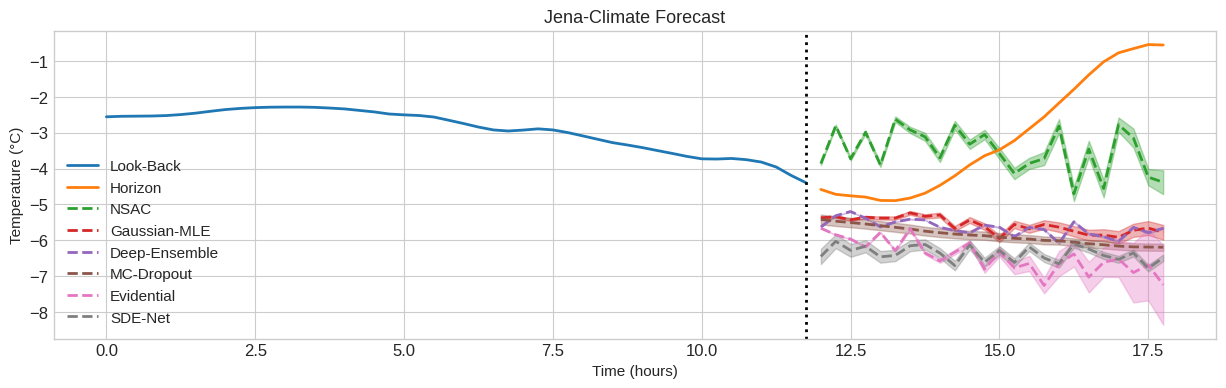

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from neuronal_attention_circuit import NAC

import pandas as pd
import numpy as np
import tensorflow as tf


from evidential_deep_learning.layers import DenseNormalGamma
from evidential_deep_learning.losses import EvidentialRegression


from sklearn.preprocessing import MinMaxScaler
from baselines import GMLE, DeepEnsemble, Evidential, MC_dropout, SDE_Net
from neuronal_attention_circuit import NAC
from ouwrap import OUWrap
from losses import NSACLoss, NLL
from neuronal_stochastic_attention_circuit import NSAC

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 11,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "lines.linewidth": 2.0,
    "lines.markersize": 3,
})

# config
LOOKBACK = 48      
HORIZON = 24
BATCH_SIZE = 64
EPOCHS = 50
TARGET_COL = 'T (degC)'  # Temperature

BASE_MODEL_NAME = 'Weather_forecast'
WEIGHTS_DIR = 'forecast_weights'
PLOTS_DIR = 'plots'
os.makedirs(WEIGHTS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)


def prepare_weather_data(file_path):
    df = pd.read_csv(file_path)
    df = df.iloc[:5000]
    features = df.drop(columns=['Date Time'])
    cols = [c for c in features.columns if c != TARGET_COL] + [TARGET_COL]
    features = features[cols]
    n_features = features.shape[1]

    n = len(features)
    train_df = features[:int(n*0.8)]
    val_df = features[int(n*0.8):int(n*0.9)]
    test_df = features[int(n*0.9):]

    scaler = MinMaxScaler()
    scaler.fit(train_df)

    train_s = scaler.transform(train_df)
    val_s = scaler.transform(val_df)
    test_s = scaler.transform(test_df)

    def create_windows(data):
        X, y = [], []
        for i in range(len(data) - LOOKBACK - HORIZON):
            X.append(data[i:i+LOOKBACK, :])
            y.append(data[i+LOOKBACK:i+LOOKBACK+HORIZON, -1])
        return np.array(X), np.array(y)

    X_train, y_train = create_windows(train_s)
    X_val, y_val = create_windows(val_s)
    X_test, y_test = create_windows(test_s)
    return X_train, y_train, X_val, y_val, X_test, y_test, scaler, n_features

X_train, y_train, X_val, y_val, X_test, y_test, scaler, n_feats= prepare_weather_data('weather.csv')

def inverse_temp(scaled_vals, scaler):
    dummy = np.zeros((len(scaled_vals), scaler.n_features_in_))
    dummy[:, -1] = scaled_vals  # target column
    return scaler.inverse_transform(dummy)[:, -1]

def plot_forecasts(num_samples=5, start_idx=0):
    color_list = ["tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan"]
    scales = {"NSAC": 10.5,  "Gaussian-MLE": 5.0,  "Deep-Ensemble": 1.0,  "MC-Dropout": 0.001,  "Evidential": 3.5,  "SDE-Net": 0.0003,}

    time_axis = np.arange(LOOKBACK + HORIZON) * 0.25
    idxs = list(range(start_idx, start_idx + num_samples))
    history = np.mean([inverse_temp(X_test[i][:, -1], scaler) for i in idxs], axis=0 )
    true_vals = np.mean([inverse_temp(y_test[i], scaler) for i in idxs], axis=0)

    plt.figure(figsize=(15, 4))
    plt.plot(time_axis[:LOOKBACK], history, label="Look-Back", linewidth=2)
    plt.plot(time_axis[LOOKBACK:], true_vals, label="Horizon", linewidth=2)
    temp_range = scaler.data_max_[-1] - scaler.data_min_[-1]

    for i, name in enumerate(MODEL_LIST):
        color = color_list[i % len(color_list)]
        mu, std = preds[name]
        avg_mu = np.mean([inverse_temp(mu[j], scaler) for j in idxs], axis=0)
        avg_std = np.mean([std[j] * temp_range for j in idxs], axis=0)
        x = time_axis[LOOKBACK:]
        plt.plot(x, avg_mu, linestyle="--", linewidth=2, color=color, label=name)
        plt.fill_between(x, avg_mu - scales[name] * avg_std, avg_mu + scales[name] * avg_std, color=color, alpha=0.35)
    plt.axvline( time_axis[LOOKBACK - 1],  color="black",  linestyle=":")
    plt.title(f"Jena-Climate Forecast")
    plt.xlabel("Time (hours)")
    plt.ylabel("Temperature (°C)")
    plt.grid(True)
    plt.legend()
    plt.savefig(f"{PLOTS_DIR}/{BASE_MODEL_NAME}_forecast.png")
    plt.show()


# all models
def _build_nsac():
    def model_fn():
        inputs = tf.keras.Input(shape=(LOOKBACK, n_feats))
        mean, std = OUWrap(
            NAC(d_model=64, num_heads=4, topk=32),
            output_dim=HORIZON,
            activation="relu"
        )(inputs)
        return tf.keras.Model(inputs, [mean, std])
    model = NSAC(stochastic_model_fn=model_fn(), ood_std=5.0, mc_samples=5)
    model.compile(optimizer=tf.keras.optimizers.AdamW(1e-4),loss=NSACLoss())
    return model

def _build_mle():
    def model_fn():
        inputs = tf.keras.Input(shape=(LOOKBACK, n_feats))
        attn = NAC(d_model=64, num_heads=4, topk=32, activation='relu')(inputs)
        mu = tf.keras.layers.Dense(HORIZON)(attn)
        log_std = tf.keras.layers.Dense(HORIZON)(attn)
        return tf.keras.Model(inputs, [mu, log_std])
    model = GMLE(model_fn())
    model.compile(optimizer=tf.keras.optimizers.AdamW(1e-4), loss=NLL())
    return model

def _build_deep_ensemble():
    def model_fn():
        inputs = tf.keras.Input(shape=(LOOKBACK, n_feats))
        attn = NAC(d_model=64, num_heads=4, topk=32, activation='relu')(inputs)
        mu = tf.keras.layers.Dense(HORIZON)(attn)
        log_std = tf.keras.layers.Dense(HORIZON)(attn)
        return tf.keras.Model(inputs, [mu,log_std])
    model = DeepEnsemble(model_fn=model_fn(),num_models=3)
    model.compile(optimizer=tf.keras.optimizers.AdamW(1e-4), loss=NLL())
    return model


def _build_mc_dropout():
    def model_fn(dropout_rate=0.1):
        inputs = tf.keras.Input(shape=(LOOKBACK, n_feats))
        attn = NAC(d_model=64, num_heads=4, topk=32, activation='relu')(inputs)
        drop = tf.keras.layers.Dropout(dropout_rate)(attn, training=True)
        mu = tf.keras.layers.Dense(HORIZON)(drop)
        log_std = tf.keras.layers.Dense(HORIZON)(drop)
        return tf.keras.Model(inputs, [mu, log_std])
    model = MC_dropout(model_fn=model_fn(),mc_samples=5)
    model.compile(optimizer=tf.keras.optimizers.AdamW(1e-4), loss=NLL())
    return model

def _build_evidential():
    def model_fn():
        inputs = tf.keras.Input(shape=(LOOKBACK, n_feats))
        attn = NAC(d_model=64, num_heads=4, topk=32, activation='relu')(inputs)
        outputs = DenseNormalGamma(HORIZON)(attn)
        return tf.keras.Model(inputs, outputs)

    model = Evidential(model_fn=model_fn(), lambda_reg=0.5)
    model.compile(optimizer=tf.keras.optimizers.AdamW(1e-4), loss=EvidentialRegression)
    return model

def _build_sde_net():
    model = SDE_Net(input_dim=672, output_dim=HORIZON, hidden_dim=64, layer_depth=6)
    model.compile(
        optimizer_drift = tf.keras.optimizers.AdamW(0.0001),
        optimizer_fc = tf.keras.optimizers.AdamW(0.0001),
        optimizer_dsl = tf.keras.optimizers.AdamW(0.0001),
        optimizer_diffusion = tf.keras.optimizers.AdamW(0.001),
        loss = NLL()
    )
    return model


MODEL_LIST = ["NSAC", "Gaussian-MLE", "Deep-Ensemble", "MC-Dropout", "Evidential", "SDE-Net"]

results = {}
preds = {}


for name in MODEL_LIST:
    print(f"\n===== Training {name} =====")

    if name == "NSAC":
        model = _build_nsac()
    elif name == "Gaussian-MLE":
        model = _build_mle()
    elif name == "Deep-Ensemble":
        model = _build_deep_ensemble()
    elif name == "MC-Dropout":
        model = _build_mc_dropout()
    elif name == "Evidential":
        model = _build_evidential()  
    elif name == "SDE-Net":
        model = _build_sde_net()

    # callbacks = [
    #     # EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    #     ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3),
    #     # ModelCheckpoint(f"{WEIGHTS_DIR}/{BASE_MODEL_NAME}_{name}.keras",monitor='val_loss',save_best_only=True)
    # ]

    # history = model.fit(
    #     X_train, y_train,
    #     validation_data=(X_val, y_val),
    #     epochs=EPOCHS,
    #     batch_size=BATCH_SIZE,
    #     # callbacks=callbacks,
    #     verbose=1
    # )
    
    model.load_weights(f"{WEIGHTS_DIR}/{BASE_MODEL_NAME}_{name}.keras")
    preds[name] = model.predict(X_test)

plot_forecasts(num_samples=5, start_idx=100)